### 特徵工程 (Feature Engineering)

本檔案主要功能為建立特徵以供後續建模、定義 A/B 群組以供 SHAP 計算。

In [8]:
"""
Feature Engineering Pipeline for NBA Salary Valuation System
核心任務：將資料轉換為模型可用格式，並定義 Group A (實力) 與 Group B (市場雜訊) 分組。
"""

import pandas as pd
import numpy as np
from typing import List, Tuple, Dict, Optional
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


def define_ab_groups(df: pd.DataFrame) -> Tuple[List[str], List[str]]:
    """
    動態分類 Group A 與 Group B。
    自動抓取所有帶有 _reg, _playoff 後綴的特徵。
    """
    # Group A: 純實力與狀態
    # 包含所有加權統計數據、年齡、傷病、季後賽經驗等
    group_a_features = ['age', 'has_playoff_exp']
    
    # 動態抓取所有統計特徵
    stat_cols = [col for col in df.columns if col.endswith('_reg') or col.endswith('_playoff')]
    group_a_features.extend(stat_cols)

    # Group B: 外部市場干擾
    # 包含 CBA 規則與市場供需變數
    group_b_features = [
        'is_retained',     # 是否與母隊續約 (鳥權溢價)
        # 由於我們沒有額外收集 PO/TO，所以這裡目前只有 is_retained
    ]

    return group_a_features, group_b_features


def create_interaction_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    基於我們合併後的特徵，建立有意義的互動特徵。
    """
    df = df.copy()

    # 1. 季後賽硬漢指數 (Playoff Elevation)
    # 若該球員有打季後賽，他的季後賽 VORP 或 BPM 是否高於例行賽？
    if 'VORP_reg' in df.columns and 'VORP_playoff' in df.columns:
        df['VORP_Elevation'] = np.where(
            df['has_playoff_exp'] == 1,
            df['VORP_playoff'] - df['VORP_reg'],
            0 # 沒打季後賽的，提升值為 0
        )
        logger.info("Created feature: VORP_Elevation")
        
    if 'BPM_reg' in df.columns and 'BPM_playoff' in df.columns:
         df['BPM_Elevation'] = np.where(
            df['has_playoff_exp'] == 1,
            df['BPM_playoff'] - df['BPM_reg'],
            0
        )
         logger.info("Created feature: BPM_Elevation")

    # 2. 季後賽時間佔比
    if 'MP_reg' in df.columns and 'MP_playoff' in df.columns:
        # 計算總上場時間 (粗估)
        total_mp_reg = df['MP_reg'] * df['G_reg']
        total_mp_playoff = df['MP_playoff'] * df['G_playoff']
        df['Playoff_MP_Ratio'] = np.where(
            total_mp_reg + total_mp_playoff > 0,
            total_mp_playoff / (total_mp_reg + total_mp_playoff),
            0
        )
        logger.info("Created feature: Playoff_MP_Ratio")

    return df


def prepare_features_for_modeling(
    df: pd.DataFrame,
    target_col: str = 'Cap_Pct'
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]: # 加上型別提示
    """
    為 XGBoost (預測定價) 與 Ordinal Logistic (預測年限) 準備最終的 X 和 y。
    """
    df = df.copy()
    
    # 確保不會有遺漏的 NA 值 (特別是互動特徵可能產生的)
    df = df.fillna(0)

    # 定義標識與目標欄位
    id_cols = ['Player', 'year']
    target_pct = target_col
    target_yrs = 'YRS'
    
    exclude_cols = id_cols + [target_pct, target_yrs]
    
    # 分離特徵矩陣、目標變數與識別欄位
    X = df.drop(columns=exclude_cols, errors='ignore')
    y_pct = df[target_pct] if target_pct in df.columns else None
    y_yrs = df[target_yrs] if target_yrs in df.columns else None
    
    # [修改處] 將識別欄位獨立為一個 DataFrame
    ids = df[id_cols] 

    logger.info(f"Prepared Feature Matrix (X) shape: {X.shape}")
    
    # 回傳 ids
    return X, y_pct, y_yrs, ids

def engineer_nba_features(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, List[str], List[str]]:
    """
    一鍵執行特徵工程管線。
    輸入為 clean.py / merge 產出的合併 DataFrame。
    """
    logger.info("--- Starting Feature Engineering ---")

    # 1. 建立互動特徵
    df = create_interaction_features(df)
    
    # 2. 定義 A/B 組
    group_a, group_b = define_ab_groups(df)
    
    new_features = ['VORP_Elevation', 'BPM_Elevation', 'Playoff_MP_Ratio']
    group_a.extend([f for f in new_features if f in df.columns])
    
    # 3. 準備最終特徵矩陣 [修改處：接收 ids]
    X, y_pct, y_yrs, ids = prepare_features_for_modeling(df) 
    
    # 確保 group 內的特徵都存在於 X 中
    group_a = [f for f in group_a if f in X.columns]
    group_b = [f for f in group_b if f in X.columns]
    
    logger.info(f"Final Group A (Skill) count: {len(group_a)}")
    logger.info(f"Final Group B (Noise) count: {len(group_b)}")
    logger.info("--- Feature Engineering Completed ---")
    
    # [修改處：回傳 ids]
    return X, y_pct, y_yrs, ids, group_a, group_b

In [15]:
df = pd.read_csv('../../data/processed/merged_weighted_stats.csv')
X, y_pct, y_yrs, ids, group_a, group_b = engineer_nba_features(df)

2026-06-03 18:05:20,042 - INFO - --- Starting Feature Engineering ---
2026-06-03 18:05:20,043 - INFO - Created feature: VORP_Elevation
2026-06-03 18:05:20,044 - INFO - Created feature: BPM_Elevation
2026-06-03 18:05:20,045 - INFO - Created feature: Playoff_MP_Ratio


2026-06-03 18:05:20,048 - INFO - Prepared Feature Matrix (X) shape: (752, 96)
2026-06-03 18:05:20,048 - INFO - Final Group A (Skill) count: 95
2026-06-03 18:05:20,049 - INFO - Final Group B (Noise) count: 1
2026-06-03 18:05:20,049 - INFO - --- Feature Engineering Completed ---


In [16]:
X

,is_retained,age,has_playoff_exp,2P%_reg,2PA_reg,2P_reg,3P%_reg,3PA_reg,3PAr_reg,3P_reg,...,TRB_playoff,TS%_playoff,USG%_playoff,VORP_playoff,WS/48_playoff,WS_playoff,eFG%_playoff,VORP_Elevation,BPM_Elevation,Playoff_MP_Ratio
0,1,28.0,1,0.5439,8.59,4.65,0.4303,9.98,0.5361,4.30,...,5.75,0.6318,30.83,1.76,0.2272,3.05,0.5797,-5.62,-0.29,0.196243
1,1,27.0,0,0.5090,15.40,7.80,0.3479,1.18,0.0714,0.38,...,8.09,0.5579,28.62,3.04,0.1729,6.79,0.5089,0.00,0.00,0.500000
2,0,26.0,0,0.4923,10.32,5.07,0.3765,4.94,0.3251,1.86,...,5.18,0.5786,26.75,4.04,0.1754,9.61,0.5159,0.00,0.00,0.500000
3,1,26.0,0,0.4862,9.67,4.74,0.3544,3.98,0.2912,1.40,...,3.53,0.5291,25.04,1.79,0.0935,3.60,0.4991,0.00,0.00,0.500000
4,0,23.0,0,0.5470,5.48,2.99,0.3945,3.51,0.3773,1.44,...,5.36,0.5878,15.43,2.41,0.1406,6.92,0.5653,0.00,0.00,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
747,1,32.0,0,0.5942,4.45,2.65,0.3789,2.65,0.3664,1.02,...,5.39,0.6356,18.39,1.35,0.1191,4.06,0.5863,0.00,0.00,0.500000
748,1,30.0,0,0.5994,3.69,2.24,0.4340,0.13,0.0404,0.03,...,4.27,0.6347,14.62,-0.05,0.1199,1.53,0.6069,0.00,0.00,0.500000
749,1,36.0,0,0.4791,3.76,1.80,0.4181,5.37,0.5916,2.26,...,2.86,0.6028,17.07,2.49,0.1604,7.09,0.5676,0.00,0.00,0.500000
750,1,27.0,0,0.5695,1.78,1.02,0.3428,2.21,0.5506,0.73,...,4.56,0.5541,9.95,0.76,0.1098,2.99,0.5375,0.00,0.00,0.500000


## EDA

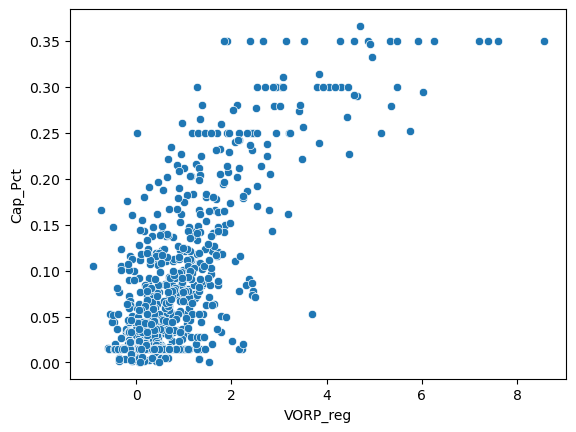

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 暫時合併進行繪圖
eda_df = X.copy()
eda_df['Cap_Pct'] = y_pct

# 看看例行賽 VORP 跟起薪佔比的關係
sns.scatterplot(data=eda_df, x='VORP_reg', y='Cap_Pct')
plt.show()

2026-06-03 18:11:15,706 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-03 18:11:15,713 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


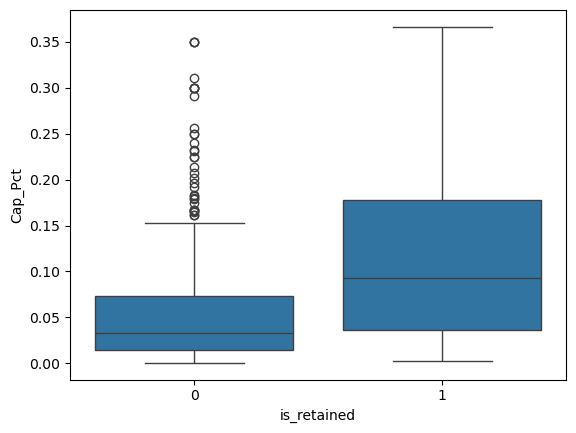

In [23]:
sns.boxplot(data=eda_df, x='is_retained', y='Cap_Pct')
plt.show()

## model_building

In [27]:
# 利用 ids 裡面的 year 來做遮罩 (Mask)
train_mask = ids['year'] <= 2022
test_mask = ids['year'] > 2022

X_train, y_pct_train = X[train_mask], y_pct[train_mask]
X_test, y_pct_test = X[test_mask], y_pct[test_mask]

In [28]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
import xgboost as xgb
import shap
import logging
import pickle
import os

In [33]:
def train_pricing_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series):
    """
    訓練 XGBoost 定價模型 (預測 Cap_Pct)
    """
    logger.info("開始訓練定價模型 (XGBoost)...")
    
    # 這裡我們先設定一組合理的 Baseline 參數，實務上你可以加入 Optuna 調參
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False
    )
    
    # 評估模型
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    logger.info(f"定價模型訓練完成！ 測試集 R2: {r2:.4f}, RMSE: {rmse:.4f}")
    return model


def train_duration_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series):
    """
    訓練合約年限模型 (Ordinal Logistic Regression 的替代實作)
    """
    logger.info("開始訓練年限模型 (Logistic Regression)...")
    
    # 雖然最理想是使用 Ordinal Logistic，但在 sklearn 中最簡單且穩定的實作是
    # 帶有 ordinal 特性的分類器，或者直接使用 Logistic Regression 處理多分類 (multi_class='multinomial')
    # 為了維持輕量化，我們這裡使用 multinomial LogisticRegression 作為展示
    
    model = LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    )
    
    # Logistic Regression 對特徵尺度敏感，實務上 X_train 應該先做 Standard Scaling
    # 但為了維持 SHAP 解釋性，這裡我們先直接訓練 (若效能不佳再加入 Scaler)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    logger.info(f"年限模型訓練完成！ 測試集 Accuracy: {acc:.4f}")
    return model


def extract_pure_skill(model, X_test: pd.DataFrame, ids_test: pd.DataFrame, group_a: list, group_b: list):
    """
    使用 SHAP 剝離純實力與市場雜訊。
    回傳一份帶有 SHAP 解析的 DataFrame。
    """
    logger.info("開始執行 SHAP 雜訊剝離...")
    
    # 初始化 TreeExplainer
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    base_value = explainer.expected_value
    
    results = []
    
    # 遍歷測試集中的每一位球員
    for i in range(len(X_test)):
        player_name = ids_test.iloc[i]['Player']
        contract_year = ids_test.iloc[i]['year']
        
        # 取得該球員的 SHAP 陣列
        player_shap = shap_values[i]
        
        # 1. 計算純實力 (Group A 特徵貢獻總和)
        skill_impact = sum([player_shap[X_test.columns.get_loc(f)] for f in group_a if f in X_test.columns])
        pure_skill_pct = base_value + skill_impact
        
        # 2. 計算市場雜訊 (Group B 特徵貢獻總和)
        noise_impact = sum([player_shap[X_test.columns.get_loc(f)] for f in group_b if f in X_test.columns])
        
        # 總預測佔比
        total_pred_pct = pure_skill_pct + noise_impact
        
        results.append({
            'Player': player_name,
            'Year': contract_year,
            'Base_Value': base_value,
            'Pure_Skill_Impact': skill_impact,
            'Pure_Skill_Valuation': pure_skill_pct,
            'Market_Noise_Impact': noise_impact,
            'Total_Predicted_Cap_Pct': total_pred_pct
        })
        
    results_df = pd.DataFrame(results)
    logger.info("SHAP 解析完成！")
    return explainer, shap_values, results_df


def save_models(pricing_model, duration_model, explainer, output_dir='../../models'):
    """儲存模型與 Explainer，供 Streamlit 應用程式載入"""
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    with open(os.path.join(output_dir, 'pricing_model.pkl'), 'wb') as f:
        pickle.dump(pricing_model, f)
        
    with open(os.path.join(output_dir, 'duration_model.pkl'), 'wb') as f:
        pickle.dump(duration_model, f)
        
    with open(os.path.join(output_dir, 'shap_explainer.pkl'), 'wb') as f:
        pickle.dump(explainer, f)
        
    logger.info(f"模型與 Explainer 已儲存至 {output_dir}")


if __name__ == "__main__":
    
    ## 資料切分 (Time-based Split) ---
    #假設用 2017-2022 訓練，2023-2024 測試
    train_mask = ids['year'] <= 2022
    test_mask = ids['year'] > 2022
    
    X_train, y_pct_train, y_yrs_train = X[train_mask], y_pct[train_mask], y_yrs[train_mask]
    X_test, y_pct_test, y_yrs_test = X[test_mask], y_pct[test_mask], y_yrs[test_mask]
    ids_test = ids[test_mask]
    
    # 2. 訓練雙模型
    pricing_model = train_pricing_model(X_train, y_pct_train, X_test, y_pct_test)
    duration_model = train_duration_model(X_train, y_yrs_train, X_test, y_yrs_test)
    
    # 3. 執行 SHAP 剝離
    explainer, shap_values, shap_results_df = extract_pure_skill(
        pricing_model, X_test, ids_test, group_a, group_b
    )
    
    # 列印幾個測試案例
    print("\n--- SHAP 雜訊剝離結果預覽 ---")
    print(shap_results_df.head())
    
    # 4. 儲存模型
    save_models(pricing_model, duration_model, explainer)

2026-06-03 18:20:54,217 - INFO - 開始訓練定價模型 (XGBoost)...
2026-06-03 18:20:55,203 - INFO - 定價模型訓練完成！ 測試集 R2: 0.7928, RMSE: 0.0410
2026-06-03 18:20:55,203 - INFO - 開始訓練年限模型 (Logistic Regression)...
c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea


--- SHAP 雜訊剝離結果預覽 ---
            Player  Year  Base_Value  Pure_Skill_Impact  Pure_Skill_Valuation  \
0     jerami grant  2023    0.090019           0.123801              0.213820   
1    fred vanvleet  2023    0.090019           0.104470              0.194489   
2     kyrie irving  2023    0.090019           0.206459              0.296478   
3   draymond green  2023    0.090019           0.025135              0.115153   
4  cameron johnson  2023    0.090019           0.034861              0.124879   

   Market_Noise_Impact  Total_Predicted_Cap_Pct  
0             0.006535                 0.220355  
1            -0.005764                 0.188725  
2             0.003617                 0.300094  
3             0.003126                 0.118280  
4             0.003335                 0.128214  


2026-06-03 18:27:06,849 - INFO - 開始 HalvingGridSearchCV 調參中 (這會花一點時間)...
2026-06-03 18:27:37,741 - INFO - 🏆 最佳參數組合: {'colsample_bytree': 1.0, 'max_depth': 5, 'min_child_weight': 10, 'subsample': 1.0, 'n_estimators': 800}
2026-06-03 18:27:37,750 - INFO - 定價模型測試集表現 -> R2: 0.7841, RMSE: 0.0418
2026-06-03 18:27:37,751 - INFO - 開始訓練年限模型 (已加入 StandardScaler)...
c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
2026-06-03 18:27:37,842 - INFO - 年限模型測試集表現 -> Accuracy: 0.4227
2026-06-03 18:27:37,843 - INFO - 開始執行 SHAP 雜訊剝離...
2026-06-03 18:27:38,089 - INFO - SHAP 解析完成！
2026-06-03 18:27:38,774 - INFO - 已儲存 kyrie irving 的 SHAP 瀑布圖至: ../../reports/figures\shap_waterfall_kyrie_irving_2023.png


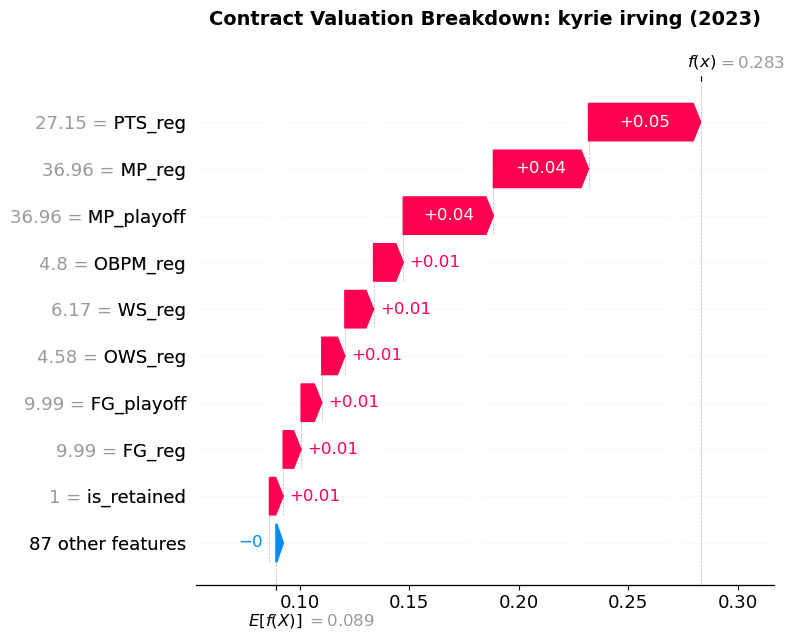

In [35]:
"""
Model Training & SHAP Extraction Pipeline for NBA Salary Valuation
包含：XGBoost 減半網格調參、標準化 Logistic Regression、以及 SHAP 視覺化圖表匯出。
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import os
import logging

from xgboost import XGBRegressor
from sklearn.experimental import enable_halving_search_cv  # 必須引入才能使用 HalvingGridSearchCV
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


def train_pricing_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series):
    """
    使用 HalvingGridSearchCV 訓練並調參 XGBoost 定價模型
    """
    logger.info("開始 HalvingGridSearchCV 調參中 (這會花一點時間)...")
    
    # 1. 初始化模型
    reg = XGBRegressor(enable_categorical=True, learning_rate=0.1, random_state=42)
    
    # 2. 設定參數網格
    param_grid = {
        "max_depth": [3, 5, 7, 9],            # 樹的深度
        "min_child_weight": [1, 5, 10],       # 節點分裂限制
        "subsample": [0.8, 1.0],              # 樣本隨機抽樣
        "colsample_bytree": [0.8, 1.0]        # 特徵隨機抽樣
    }
    
    # 3. 進行逐次減半網格搜索
    search = HalvingGridSearchCV(
        estimator=reg, 
        param_grid=param_grid, 
        resource='n_estimators', 
        min_resources=50,       
        max_resources=800,      
        factor=2,               
        cv=3,                   
        scoring='neg_root_mean_squared_error',  
        random_state=42,
        n_jobs=-1
    )
    
    # 訓練並尋找最佳參數
    search.fit(X_train, y_train)
    
    logger.info(f"🏆 最佳參數組合: {search.best_params_}")
    
    # 提取最強模型
    best_model = search.best_estimator_
    
    # 評估模型
    y_pred = best_model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    logger.info(f"定價模型測試集表現 -> R2: {r2:.4f}, RMSE: {rmse:.4f}")
    return best_model


def train_duration_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series):
    """
    使用 Pipeline (StandardScaler + LogisticRegression) 訓練年限模型
    """
    logger.info("開始訓練年限模型 (已加入 StandardScaler)...")
    
    # 建立管線，資料會先經過標準化，再進入分類器
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
            multi_class='multinomial', 
            solver='lbfgs', 
            max_iter=1000, 
            random_state=42
        ))
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    logger.info(f"年限模型測試集表現 -> Accuracy: {acc:.4f}")
    return pipeline


def extract_pure_skill(model, X_test: pd.DataFrame, ids_test: pd.DataFrame, group_a: list, group_b: list):
    """
    使用 SHAP 剝離純實力與市場雜訊，回傳 SHAP 數值物件與分析表格。
    """
    logger.info("開始執行 SHAP 雜訊剝離...")
    
    # 使用新版 API，直接回傳 Explanation 物件，方便後續畫圖
    explainer = shap.TreeExplainer(model)
    shap_values_obj = explainer(X_test) 
    
    base_value = explainer.expected_value
    results = []
    
    for i in range(len(X_test)):
        player_name = ids_test.iloc[i]['Player']
        contract_year = ids_test.iloc[i]['year']
        
        # 這裡從 Explanation 物件中抽出純數值陣列來計算總和
        player_shap_vals = shap_values_obj.values[i]
        
        skill_impact = sum([player_shap_vals[X_test.columns.get_loc(f)] for f in group_a if f in X_test.columns])
        pure_skill_pct = base_value + skill_impact
        noise_impact = sum([player_shap_vals[X_test.columns.get_loc(f)] for f in group_b if f in X_test.columns])
        
        total_pred_pct = pure_skill_pct + noise_impact
        
        results.append({
            'Player': player_name,
            'Year': contract_year,
            'Base_Value': base_value,
            'Pure_Skill_Impact': skill_impact,
            'Pure_Skill_Valuation': pure_skill_pct,
            'Market_Noise_Impact': noise_impact,
            'Total_Predicted_Cap_Pct': total_pred_pct
        })
        
    results_df = pd.DataFrame(results)
    logger.info("SHAP 解析完成！")
    return explainer, shap_values_obj, results_df


def plot_player_shap_waterfall(shap_values_obj, X_test: pd.DataFrame, ids_test: pd.DataFrame, player_name: str, target_year: int, output_dir: str = '../../reports/figures'):
    """
    繪製並儲存特定球員的 SHAP 瀑布圖 (Waterfall Plot)
    """
    # 尋找該球員在測試集中的索引位置
    match_idx = np.where((ids_test['Player'] == player_name) & (ids_test['year'] == target_year))[0]
    
    if len(match_idx) == 0:
        logger.warning(f"圖表生成失敗：找不到 {player_name} 在 {target_year} 年的測試集資料。")
        return
    
    player_idx = match_idx[0]
    
    # 繪圖設定
    plt.figure(figsize=(10, 6))
    
    # 呼叫 SHAP 內建的瀑布圖，max_display 決定顯示幾個最關鍵的特徵
    shap.plots.waterfall(shap_values_obj[player_idx], max_display=10, show=False)
    
    plt.title(f"Contract Valuation Breakdown: {player_name} ({target_year})", fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    
    # 建立資料夾並存檔
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        
    safe_name = player_name.replace(" ", "_").lower()
    file_path = os.path.join(output_dir, f"shap_waterfall_{safe_name}_{target_year}.png")
    plt.savefig(file_path, dpi=300, bbox_inches='tight')
    
    logger.info(f"已儲存 {player_name} 的 SHAP 瀑布圖至: {file_path}")
    plt.show()

# --- 執行管線範例 ---
# 1. 訓練模型
best_pricing_model = train_pricing_model(X_train, y_pct_train, X_test, y_pct_test)
pipeline_duration_model = train_duration_model(X_train, y_yrs_train, X_test, y_yrs_test)

# 2. 執行 SHAP 解析
explainer, shap_values_obj, shap_results_df = extract_pure_skill(best_pricing_model, X_test, ids_test, group_a, group_b)

# 3. 畫出球星的價值拆解圖！
plot_player_shap_waterfall(shap_values_obj, X_test, ids_test, player_name='kyrie irving', target_year=2023)